In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset
import pandas as pd

In [3]:
dataset = load_dataset("lukebarousse/data_jobs") #Load data from hugging face using load_data method

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [4]:
type(dataset['train'])

datasets.arrow_dataset.Dataset

In [5]:
df = dataset['train'].to_pandas()

**DATA INSPECTION**

In [6]:
df.describe()

,salary_year_avg,salary_hour_avg
count,22003.000000,10662.000000
mean,123286.274072,47.016598
std,48312.449482,21.890738
min,15000.000000,8.000000
25%,90000.000000,27.500000
50%,115000.000000,45.980000
75%,150000.000000,61.159996
max,960000.000000,391.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

In [8]:
df.isnull().sum()

,0
job_title_short,0
job_title,1
job_location,1045
job_via,8
job_schedule_type,12667
job_work_from_home,0
search_location,0
job_posted_date,0
job_no_degree_mention,0
job_health_insurance,0


In [9]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [10]:
df.tail()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,NaN,NaN,Trigyn,"['aws', 'flow']","{'cloud': ['aws'], 'other': ['flow']}"


In [11]:
df['job_title_short'].head()

,job_title_short
0,Senior Data Engineer
1,Data Analyst
2,Data Engineer
3,Data Engineer
4,Data Engineer


In [12]:
df['job_title_short'].tail()

,job_title_short
785736,Software Engineer
785737,Data Analyst
785738,Business Analyst
785739,Data Engineer
785740,Software Engineer


In [13]:
df[['job_title_short', 'job_location', 'salary_rate']]

,job_title_short,job_location,salary_rate
0,Senior Data Engineer,"Watertown, CT",None
1,Data Analyst,"Guadalajara, Jalisco, Mexico",None
2,Data Engineer,"Berlin, Germany",None
3,Data Engineer,"San Antonio, TX",None
4,Data Engineer,"Washington, DC",None
...,...,...,...
785736,Software Engineer,Singapura,None
785737,Data Analyst,"Bad Rodach, Jerman",None
785738,Business Analyst,Malaysia,None
785739,Data Engineer,"Newark, New Jersey, Amerika Serikat",None


In [14]:
df.iloc[90:100, 0:3]

,job_title_short,job_title,job_location
90,Data Scientist,Data Scientist,Australia
91,Data Scientist,Data Scientist,"Temuco, Chile"
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere
93,Data Analyst,IT Finance / TBM Data Analyst - Remote | WFH,Anywhere
94,Data Engineer,Data Engineer - Cloud Operations,"Lehi, UT"
95,Data Engineer,Data Engineer,"Mumbai, Maharashtra, India"
96,Data Engineer,Data Engineer,"Torrance, CA"
97,Data Analyst,"Systems & Data Analyst - Exploitation, Missing...",United Kingdom
98,Senior Data Engineer,Senior Data Engineer (AWS),"Toronto, ON, Canada"
99,Data Engineer,Senior/Staff Data Engineer – Apache Spark (Jav...,"Miami, FL"


In [15]:
#view specific columns and rows
df[['job_title_short', 'job_title']].iloc[90:100]

,job_title_short,job_title
90,Data Scientist,Data Scientist
91,Data Scientist,Data Scientist
92,Data Engineer,Remote - Data Engineer - Permanent - W2
93,Data Analyst,IT Finance / TBM Data Analyst - Remote | WFH
94,Data Engineer,Data Engineer - Cloud Operations
95,Data Engineer,Data Engineer
96,Data Engineer,Data Engineer
97,Data Analyst,"Systems & Data Analyst - Exploitation, Missing..."
98,Senior Data Engineer,Senior Data Engineer (AWS)
99,Data Engineer,Senior/Staff Data Engineer – Apache Spark (Jav...


In [16]:
df.job_title_short.unique()

array(['Senior Data Engineer', 'Data Analyst', 'Data Engineer',
       'Business Analyst', 'Data Scientist', 'Machine Learning Engineer',
       'Senior Data Analyst', 'Cloud Engineer', 'Senior Data Scientist',
       'Software Engineer'], dtype=object)

In [17]:
df.job_country.unique()

array(['United States', 'Mexico', 'Germany', 'Sudan', 'Romania',
       'Denmark', 'Switzerland', 'France', 'Brazil', 'United Kingdom',
       'India', 'Poland', 'Belgium', 'Russia', 'Serbia', 'Singapore',
       'Costa Rica', 'Ireland', 'Italy', 'Malaysia', 'Canada', 'Uruguay',
       'Namibia', 'Estonia', 'Israel', 'Hungary', 'Austria',
       'Philippines', 'Egypt', 'Australia', 'Chile', 'Spain',
       'Netherlands', 'South Africa', 'Colombia', 'Hong Kong', 'Kuwait',
       'Finland', 'Luxembourg', 'China', 'Puerto Rico', 'Sweden',
       'Saudi Arabia', 'Argentina', 'Turkey', 'Panama', 'Nigeria',
       'New Zealand', 'Ukraine', 'Jordan', 'United Arab Emirates',
       'Armenia', 'Pakistan', 'Lesotho', 'Mauritius', 'Portugal',
       'Bahrain', 'Taiwan', "Côte d'Ivoire", 'U.S. Virgin Islands',
       'Réunion', 'Kazakhstan', 'Lithuania', 'Moldova', 'Belarus',
       'Cyprus', 'Bulgaria', 'Honduras', 'Czechia', 'Peru', 'South Korea',
       'Malta', 'Indonesia', 'Tunisia', 'Latvia'

In [18]:
type(df.job_title_short)

pandas.core.series.Series

In [19]:
#Filtering specific data

from numpy import empty
df[(df.job_title_short == 'Data Analyst') & (df.salary_year_avg.notna()) & (df.job_country == 'Brazil')]

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36013,Data Analyst,Data Analyst,"São Paulo, State of São Paulo, Brazil",via Ai-Jobs.net,Full-time,False,Brazil,2023-08-01 13:22:38,True,False,Brazil,year,57500.0,NaN,Media.Monks,"['express', 'excel', 'looker', 'sheets']","{'analyst_tools': ['excel', 'looker', 'sheets'..."
55315,Data Analyst,Staff Data Analytics | Global Analytics,Brazil,via Ai-Jobs.net,Full-time,False,Brazil,2023-05-24 06:19:58,True,False,Brazil,year,79200.0,NaN,Gympass,"['sql', 'tableau']","{'analyst_tools': ['tableau'], 'programming': ..."
144588,Data Analyst,[JOB-9652 ] Data Analytics Mid,"Campinas, State of São Paulo, Brazil",via Ai-Jobs.net,Full-time,False,Brazil,2023-02-09 08:34:07,False,False,Brazil,year,79200.0,NaN,CI&T,"['sql', 'python', 'r', 'snowflake', 'power bi'...","{'analyst_tools': ['power bi', 'tableau'], 'cl..."
237974,Data Analyst,[Job- 11490] Mid Level Data Visualization Anal...,Brazil,via Ai-Jobs.net,Full-time,False,Brazil,2023-08-23 07:31:59,True,False,Brazil,year,64800.0,NaN,CI&T,"['sql', 'python', 'azure', 'tableau', 'flow']","{'analyst_tools': ['tableau'], 'cloud': ['azur..."
243537,Data Analyst,Project Manager - Infrastructure/Planning/Data...,Brazil,via Ai-Jobs.net,Full-time,False,Brazil,2023-09-15 07:41:22,False,False,Brazil,year,50400.0,NaN,Turner & Townsend,"['vba', 'sql', 'oracle', 'excel', 'power bi']","{'analyst_tools': ['excel', 'power bi'], 'clou..."
392204,Data Analyst,[Job 11234] Mid-Level Data Analyst - Brasil,Brazil,via Ai-Jobs.net,Full-time,False,Brazil,2023-08-04 18:17:10,True,False,Brazil,year,100500.0,NaN,CI&T,"['sql', 'python', 'databricks', 'azure']","{'cloud': ['databricks', 'azure'], 'programmin..."
403313,Data Analyst,"Data Analyst, Merchant Health","São Paulo, State of São Paulo, Brazil",via Ai-Jobs.net,Full-time,False,Brazil,2023-03-17 18:32:58,True,False,Brazil,year,53014.0,NaN,Riskified,"['r', 'sql', 'python']","{'programming': ['r', 'sql', 'python']}"
474556,Data Analyst,Product Data Analyst | Bees Martech,Brazil,via Ai-Jobs.net,Full-time,False,Brazil,2023-01-26 14:25:36,False,False,Brazil,year,98500.0,NaN,BEES,None,None
507704,Data Analyst,Data Analyst | Lisboa/ Porto,Brazil,via Ai-Jobs.net,Full-time,False,Brazil,2023-12-24 11:17:58,False,False,Brazil,year,75067.5,NaN,NOS SGPS,"['sas', 'sas', 'mysql', 'oracle', 'power bi']","{'analyst_tools': ['sas', 'power bi'], 'cloud'..."
562572,Data Analyst,Data Analyst (Python),"Cotia - Caucaia do Alto, Cotia - State of São ...",via Ai-Jobs.net,Full-time,False,Brazil,2023-04-26 04:27:35,False,False,Brazil,year,102500.0,NaN,NielsenIQ,"['python', 'sql']","{'programming': ['python', 'sql']}"


**DATA CLEANING**

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

In [21]:
type(df.job_posted_date[0])

str

In [22]:
#change the job_posted_date from string to date object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [23]:
type(df.job_posted_date[0])

pandas._libs.tslibs.timestamps.Timestamp

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [25]:
df[df.job_posted_date.dt.year == 2023] #Filtering jobs posted on 2023

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [26]:
df['job_posted_month'] = df.job_posted_date.dt.month #Creating a new column and inserting the month data

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [28]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None,6
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",10
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",8


In [29]:
#Sorting data using the job_posted_date column
df.sort_values(by= 'job_posted_date', inplace=True)

In [30]:
df.drop(labels= 'salary_hour_avg', axis=1, inplace=True)

In [31]:
df.dropna(subset=['salary_year_avg'], inplace=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22003 entries, 108883 to 327439
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        22003 non-null  object        
 1   job_title              22003 non-null  object        
 2   job_location           21723 non-null  object        
 3   job_via                22003 non-null  object        
 4   job_schedule_type      21987 non-null  object        
 5   job_work_from_home     22003 non-null  bool          
 6   search_location        22003 non-null  object        
 7   job_posted_date        22003 non-null  datetime64[ns]
 8   job_no_degree_mention  22003 non-null  bool          
 9   job_health_insurance   22003 non-null  bool          
 10  job_country            22003 non-null  object        
 11  salary_rate            22003 non-null  object        
 12  salary_year_avg        22003 non-null  float64       
 13  

**DATA ANALYSIS**

In [33]:
df['salary_year_avg'].median()

115000.0

In [34]:
df['salary_year_avg'].min()

15000.0

In [35]:
df['salary_year_avg'].max()

960000.0

In [36]:
min_salary = df['salary_year_avg'].idxmin() #The min salary row

In [37]:
df.loc[min_salary]

,665729
job_title_short,Data Engineer
job_title,Data Engineer - Hadoop
job_location,Brazil
job_via,via LinkedIn
job_schedule_type,Full-time
job_work_from_home,False
search_location,Brazil
job_posted_date,2023-12-09 10:05:30
job_no_degree_mention,True
job_health_insurance,False


In [38]:
max_salary = df['salary_year_avg'].idxmax() #Max salary row

In [39]:
df.loc[max_salary]

,554784
job_title_short,Data Scientist
job_title,Data Scientist
job_location,"Madison, SD"
job_via,via Cooperative Career Center
job_schedule_type,Full-time
job_work_from_home,False
search_location,"Illinois, United States"
job_posted_date,2023-05-04 19:06:06
job_no_degree_mention,False
job_health_insurance,True


In [40]:
df['job_title_short'].unique()

array(['Data Scientist', 'Data Engineer', 'Business Analyst',
       'Data Analyst', 'Senior Data Engineer', 'Senior Data Scientist',
       'Senior Data Analyst', 'Software Engineer',
       'Machine Learning Engineer', 'Cloud Engineer'], dtype=object)

In [41]:
df['job_title_short'].value_counts()

,count
job_title_short,
Data Scientist,5922
Data Analyst,5451
Data Engineer,4500
Senior Data Scientist,1690
Senior Data Engineer,1591
Senior Data Analyst,1131
Business Analyst,610
Machine Learning Engineer,576
Software Engineer,467


In [42]:
df.groupby('job_title_short')[['salary_year_avg', 'job_posted_month']].median()

,salary_year_avg,job_posted_month
job_title_short,,
Business Analyst,85000.0,8.0
Cloud Engineer,90000.0,6.0
Data Analyst,90000.0,6.0
Data Engineer,125000.0,5.0
Data Scientist,127500.0,6.0
Machine Learning Engineer,106415.0,5.0
Senior Data Analyst,111175.0,6.0
Senior Data Engineer,147500.0,6.0
Senior Data Scientist,155500.0,6.0


In [43]:
df.groupby('job_title_short')['salary_year_avg'].max()

,salary_year_avg
job_title_short,
Business Analyst,387460.0
Cloud Engineer,280000.0
Data Analyst,650000.0
Data Engineer,525000.0
Data Scientist,960000.0
Machine Learning Engineer,325000.0
Senior Data Analyst,425000.0
Senior Data Engineer,425000.0
Senior Data Scientist,890000.0


In [44]:
df.groupby(['job_title_short', 'job_country', 'job_posted_date'])['salary_year_avg'].max()

job_title_short    job_country    job_posted_date    
Business Analyst   Argentina      2023-01-24 04:46:05     63000.0
                                  2023-11-03 04:33:47     79200.0
                   Australia      2023-07-19 11:23:34     63000.0
                                  2023-12-10 12:14:03    130000.0
                                  2023-12-30 22:09:13     70000.0
                                                           ...   
Software Engineer  United States  2023-12-27 16:01:21     95000.0
                                  2023-12-30 15:02:16    260775.0
                                  2023-12-31 13:03:14    317000.0
                   Vietnam        2023-03-30 05:03:21     79200.0
                                  2023-09-29 22:12:36     28000.0
Name: salary_year_avg, Length: 21796, dtype: float64

In [45]:
df.groupby('job_title_short')['salary_year_avg'].agg(['min', 'max', 'median', 'count'])

,min,max,median,count
job_title_short,,,,
Business Analyst,16500.0,387460.0,85000.0,610
Cloud Engineer,42000.0,280000.0,90000.0,65
Data Analyst,25000.0,650000.0,90000.0,5451
Data Engineer,15000.0,525000.0,125000.0,4500
Data Scientist,27000.0,960000.0,127500.0,5922
Machine Learning Engineer,30000.0,325000.0,106415.0,576
Senior Data Analyst,30000.0,425000.0,111175.0,1131
Senior Data Engineer,35000.0,425000.0,147500.0,1591
Senior Data Scientist,45000.0,890000.0,155500.0,1690


In [46]:
df['job_country'].isin(['Kenya']).any()

np.True_

In [47]:
us_jobs = df[df['job_country'] == 'United States']

In [48]:
us_jobs['job_title_short'].value_counts()

,count
job_title_short,
Data Scientist,4553
Data Analyst,4350
Data Engineer,2915
Senior Data Scientist,1241
Senior Data Engineer,1058
Senior Data Analyst,913
Business Analyst,431
Software Engineer,157
Machine Learning Engineer,128


In [49]:
us_jobs.groupby('job_title_short')['salary_year_avg'].agg(['min', 'max', 'median', 'count', 'mean', 'std']).sort_values(by='median', ascending=False)

,min,max,median,count,mean,std
job_title_short,,,,,,
Senior Data Scientist,55000.0,475000.0,155000.0,1241,159330.432029,48880.807732
Machine Learning Engineer,44408.5,315000.0,150000.0,128,154240.382812,55573.192498
Senior Data Engineer,45000.0,375000.0,150000.0,1058,151448.023186,36116.363829
Data Scientist,30000.0,960000.0,130000.0,4553,139946.707204,52791.742973
Software Engineer,48982.0,375000.0,130000.0,157,137964.929588,54015.437433
Data Engineer,23496.0,525000.0,125000.0,2915,134226.676753,42785.226304
Cloud Engineer,42000.0,221844.0,116100.0,20,120090.900000,45564.891468
Senior Data Analyst,35360.0,425000.0,110000.0,913,115729.129954,34769.663226
Business Analyst,35000.0,387460.0,90000.0,431,96175.447397,32570.729242


**DATA VISUALIZATION USING MATPLOTLIB**

In [50]:
import matplotlib.pyplot as plt
import numpy as np




plotting the job_posted_date against their count

In [51]:
date_counts = df.job_posted_date.value_counts()

In [52]:
date_counts = date_counts.sort_index()


In [53]:
month_count = df.job_posted_month.value_counts()
month_count = month_count.sort_index()
month_count

,count
job_posted_month,
1,2296
2,2010
3,2204
4,1876
5,1911
6,2331
7,2219
8,2095
9,1246


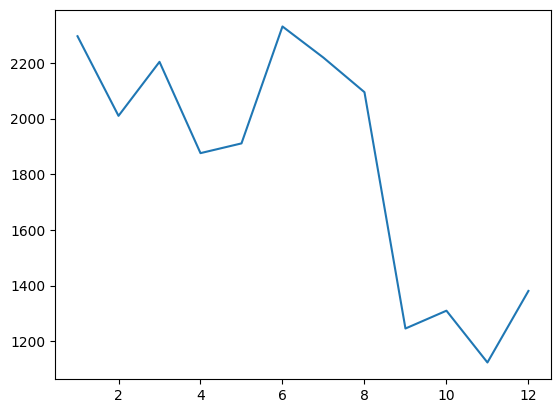

In [54]:
plt.plot(month_count.index, month_count.values)
plt.show()

In [55]:
job_title_counts = df.job_title_short.value_counts()

In [56]:
job_title_counts = job_title_counts.sort_values(ascending=True)

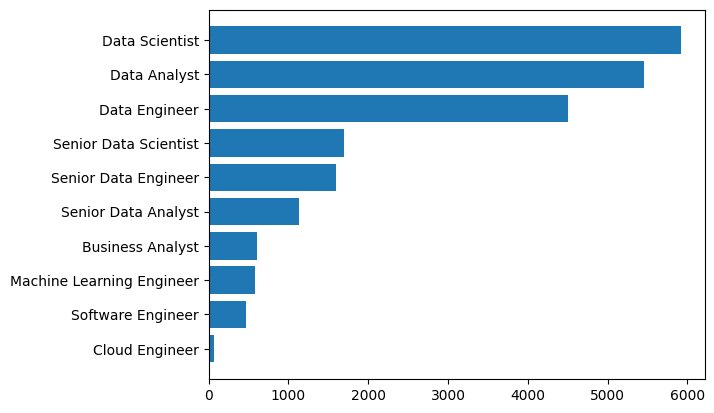

In [57]:
plt.barh(job_title_counts.index, job_title_counts, align='center')
plt.show()

In [58]:
job_title_counts = job_title_counts.sort_values(ascending=False)

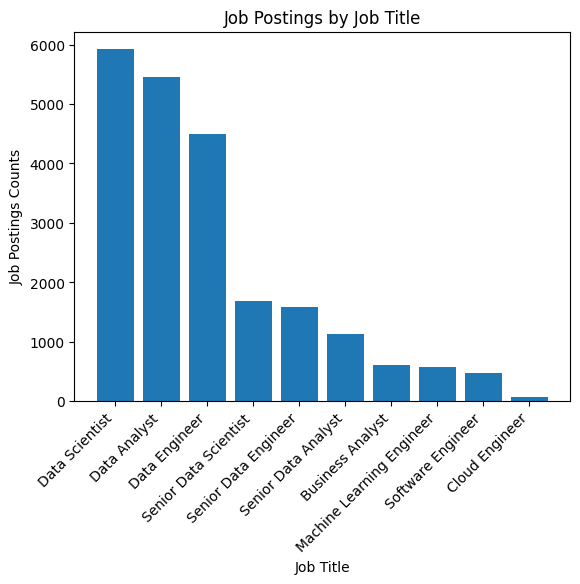

In [59]:
from matplotlib import colors
plt.bar(job_title_counts.index, job_title_counts)
plt.title('Job Postings by Job Title')
plt.ylabel('Job Postings Counts')
plt.xlabel('Job Title')
plt.xticks(rotation=45, ha='right')
plt.show()

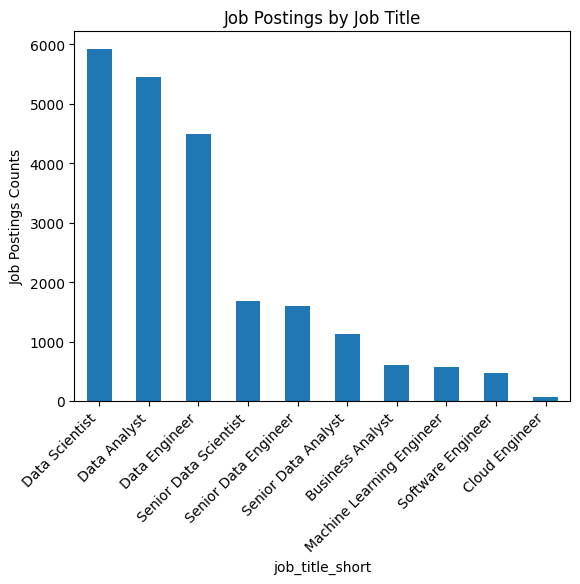

In [60]:
job_title_counts.plot(kind='bar')
plt.title('Job Postings by Job Title')
plt.ylabel('Job Postings Counts')
plt.xticks(rotation=45, ha='right')
plt.show()

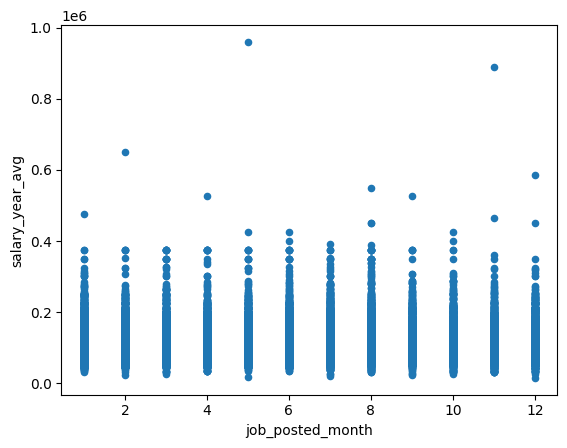

In [61]:
df.plot(kind = 'scatter', x= 'job_posted_month', y= 'salary_year_avg')
plt.show()

In [64]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()
job_salary


,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Software Engineer,99150.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Data Engineer,125000.0
Data Scientist,127500.0
Senior Data Engineer,147500.0


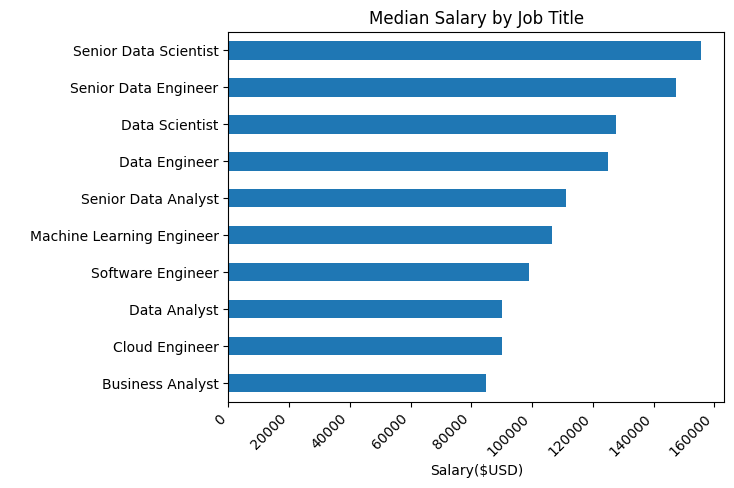

In [63]:
job_salary.plot(kind='barh')
plt.title('Median Salary by Job Title')
plt.ylabel(' ')
plt.xlabel('Salary($USD)')
plt.xticks(rotation=45, ha='right')
plt.show()